# Fading the non-voters — FOMC speaker hawk/dove, 2022 – 2026

`usd_fomc_configurable_backtest.ipynb` trades the **voters**: receive before a dove, pay before a
hawk, 3rd quarterly SR3, T−60 / T+240, nothing inside 10 days of a meeting, from 2022. This
notebook runs that book with **one edit** — the speakers the published rotation gives no vote this
year are traded the *other way*:

> **pay before a non-voting president's dovish speech, receive before their hawkish one.**

The thesis is that the market does not price a speech that carries no vote. If that is right, the
non-voter half of the roster should carry no positive drift, and taking the opposite side of the
label should at worst cost nothing — at best it should collect whatever the labels are wrong about.

### The edit, in the config

```python
CONFIG["filters"]["voters"] = "all"      # let the non-voters into the book
CONFIG["flip"]              = "nonvoters"  # ...and trade them backwards
```

`flip` is applied at **pricing**, after the one-position-at-a-time rule. That ordering is
deliberate and it is the reason this is not the voters' book with extra trades bolted on: a
non-voter's position occupies the book's single slot and can sit in front of a voter's speech.
§4 counts what that costs.

### Six books, one difference at a time

| | book | what it does with a non-voting president |
|---|---|---|
| **A** | voters only — *the notebook, unchanged* | never trades them |
| **B** | non-voters, as read | receives before their doves |
| **C** | non-voters, **FADED** | pays before their doves — `= −1 × B` by construction |
| **D** | **voters + non-voters FADED** | **the strategy this notebook is about** |
| **E** | everyone, as read | treats a non-voter's word like a voter's |
| **F** | voters FADED + non-voters as read | the mirror — it should be bad, and it is |

---

> ## ⚠ The labels are still not point-in-time
>
> The quarterly hawk/dove stances were hand-assigned in 2026 from commentary covering the whole
> period. Every number here inherits that ceiling, in both directions: a *fade* of a hindsight
> label is no more tradeable than a follow of one.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pickle, datetime, json, copy
from pathlib import Path

# The `flip` knob lives on feat/fomc-nonvoter-fade. Point REPO at whichever
# checkout carries it — after that branch merges, that is any of them.
REPO = r"C:\Users\chris\clee\ARBS-nvf"
HERE = Path(REPO) / "notebooks" / "backtests" / "intraday_fed_hawk_dove"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large",
                       "axes.labelsize": "large"})

from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP

import global_hawk_dove_common as G
import global_hawk_dove_grid as GRID
import hawk_dove_config as HC
import fomc_extras as FX
from global_hawk_dove_run import CACHE

MDP = STIRFutureMDP(source="BARCHART_STIRF-RL")
n_bars = G.load_bar_cache(CACHE / "bars.pkl")

with open(CACHE / "events_manual_raw.pkl", "rb") as f:
    RAW = pickle.load(f)["FED"]["events"]

print(f"raw event book : {len(RAW)} events, "
      f"{min(e['speech_ts'] for e in RAW).date()} -> "
      f"{max(e['speech_ts'] for e in RAW).date()}")
print(f"bar cache      : {n_bars:,} symbol-days")
print(f"flip rules     : {HC.FLIP_RULES}")

C:\Users\chris\clee\ARBS-nvf\MDP\STIRFutures\STIRFutureMDP.py:19: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  import rateslib as rl


raw event book : 1164 events, 2019-01-09 -> 2026-08-07
bar cache      : 10,704 symbol-days
flip rules     : ('none', 'nonvoters', 'voters', 'all')


## 1. The config, and the one edit

`CONFIG` below is the active config in `usd_fomc_configurable_backtest.ipynb`, copied verbatim.
Everything that follows is that dict with `filters.voters` and `flip` changed, and nothing else.

In [2]:
CONFIG = {
    "name": "A voters only (the notebook)",
    "bank": "FED",
    "instrument": {"kind": "outright", "rank": 3},
    "timing": {"entry_offset_min": -60, "exit_offset_min": 240,
               "max_staleness_min": 45, "retime_synthetic": False},
    "filters": {"start": "2022-01-01", "end": None, "voters": "voters",
                "roles": None, "speakers_include": None, "speakers_exclude": None,
                "timestamp_source": "all", "min_abs_bucket": 1, "direction": "both",
                "era": "SR3", "days_to_fomc_max": None, "days_to_fomc_min": 10,
                "weekdays": None},
    "flip": "none",                      # <- the new knob: none | nonvoters | voters | all
    "sizing": "equal",
    "cost_bp": 0,
}


def cfg(name, **over):
    """CONFIG with nested overrides — so every book below differs by what it names."""
    out = {k: (dict(v) if isinstance(v, dict) else v) for k, v in CONFIG.items()}
    out["name"] = name
    for k, v in over.items():
        out[k] = {**out[k], **v} if isinstance(v, dict) and isinstance(out.get(k), dict) else v
    return out


BOOKS = {
    "A voters only (the notebook)": cfg("A voters only (the notebook)"),
    "B non-voters, as read":        cfg("B non-voters, as read",
                                        filters={"voters": "nonvoters"}),
    "C non-voters, FADED":          cfg("C non-voters, FADED",
                                        filters={"voters": "nonvoters"}, flip="nonvoters"),
    "D voters + non-voters FADED":  cfg("D voters + non-voters FADED",
                                        filters={"voters": "all"}, flip="nonvoters"),
    "E everyone, as read":          cfg("E everyone, as read", filters={"voters": "all"}),
    "F voters FADED + non-voters as read": cfg("F voters FADED + non-voters as read",
                                               filters={"voters": "all"}, flip="voters"),
}
HEAD, COMB = "A voters only (the notebook)", "D voters + non-voters FADED"

RES = {k: HC.run_config(c, RAW, MDP) for k, c in BOOKS.items()}
A = RES[HEAD].closed
B = RES["B non-voters, as read"].closed
Cc = RES["C non-voters, FADED"].closed
D = RES[COMB].closed
E = RES["E everyone, as read"].closed
F = RES["F voters FADED + non-voters as read"].closed
print(f"{len(A)} / {len(B)} / {len(Cc)} / {len(D)} / {len(E)} / {len(F)} trades")

399 / 196 / 196 / 504 / 504 / 504 trades


## 2. Who is a non-voter, and does the knob do what it says?

A direction switch is the easiest thing in a backtest to get quietly wrong: a rule that never
fires produces a perfectly plausible book, and so does one that fires on the wrong rows. So before
any number below is read, three checks — and the third does not use the knob at all.

1. **`flip="none"` reproduces the module as it was before the knob existed.** The pre-change file
   is loaded from another checkout and run side by side, not assumed equivalent.
2. **The fade is a clean sign change.** Non-voters faded is exactly −1 × non-voters as read, on
   the same trades in the same order.
3. **The combined book priced with the knob equals the combined book priced *without* it and
   negated afterwards** on the `is_voter == False` rows. Two routes to one number.

Plus the fact the whole exercise rests on: every speaker's voting status here is *known*.
`is_voter` returns `None` where the rotation cannot say, and neither the filter nor the flip will
guess — an unknown is never treated as a non-voter.

In [3]:
import importlib.util

# --- who ------------------------------------------------------------------
attrs = [HC.event_attrs(e) for e in RAW]
unknown = sum(1 for a in attrs if a["is_voter"] is None)
nv_roles = pd.Series([a["role"] for a in attrs if a["is_voter"] is False]).value_counts()
print(f"events with unknown voting status : {unknown}")
print(f"roles of every non-voter          : {dict(nv_roles)}")
print("governors vote at every meeting, so 'non-voter' and 'president in an off year'")
print("are the same set of speeches — the flip is a cut on the published rotation only.")

# --- 1. the knob at rest changes nothing ----------------------------------
p = Path(r"C:\Users\chris\clee\ARBS-gcb") / "notebooks" / "backtests" / \
    "intraday_fed_hawk_dove" / "hawk_dove_config.py"
spec = importlib.util.spec_from_file_location("hawk_dove_config_pre", p)
PRE = importlib.util.module_from_spec(spec); sys.modules[spec.name] = PRE
spec.loader.exec_module(PRE)
assert not hasattr(PRE, "flip_sign"), "that file already has the knob — not a control"

checks = []
for nm, c in [("voters-only", cfg("x")), ("whole book", cfg("x", filters={"voters": "all"}))]:
    old = PRE.run_config(c, RAW, MDP).closed
    new = HC.run_config({**c, "flip": "none"}, RAW, MDP).closed
    cols = [x for x in old.columns if x in new.columns]
    checks.append((f"flip='none' == pre-knob module ({nm})",
                   len(old) == len(new) and old[cols].reset_index(drop=True)
                   .equals(new[cols].reset_index(drop=True)), f"{len(old)} trades"))

# --- 2. the fade is exactly a sign change ---------------------------------
checks.append(("C is exactly -1 x B",
               list(B.tag) == list(Cc.tag) and
               bool(np.array_equal(B.pnl_bp.to_numpy(), -Cc.pnl_bp.to_numpy())),
               f"{B.pnl_bp.sum():+.1f}bp -> {Cc.pnl_bp.sum():+.1f}bp"))

# --- 3. the same book, priced without the knob ----------------------------
k, pl = D.set_index("tag"), E.set_index("tag")
nv = pl.is_voter == False
manual = pl.pnl_bp.copy(); manual[nv] = -manual[nv]
checks += [
    ("D == E with the non-voter rows negated by hand",
     list(k.index) == list(pl.index) and bool(np.array_equal(k.pnl_bp.to_numpy(),
                                                             manual.to_numpy())),
     f"max diff {np.abs(k.pnl_bp.to_numpy() - manual.to_numpy()).max():.1e}"),
    ("exactly the non-voters were flipped",
     bool(((k["flip"] == -1.0) == nv).all()), f"{int((k['flip'] < 0).sum())} of {len(k)}"),
    ("no voter's trade was touched",
     bool(np.array_equal(k.pnl_bp[~nv].to_numpy(), pl.pnl_bp[~nv].to_numpy())), ""),
    ("the gate and the overlap rule are direction-blind",
     bool(np.array_equal(k.d_rate_bp.to_numpy(), pl.d_rate_bp.to_numpy())),
     "the move is a fact, only the side is a choice"),
    ("unknown voting status is never flipped", unknown == 0, "none in this book"),
    ("no bars missing", RES[COMB].funnel["n_missing_bars"] == 0, ""),
]
try:
    HC.run_config(cfg("x", flip="non-voters"), RAW, MDP)
    checks.append(("a mistyped rule raises", False, "it ran"))
except ValueError as e:
    checks.append(("a mistyped rule raises", True, str(e)[:44]))

display(pd.DataFrame([{"check": c, "result": "PASS" if ok else "FAIL", "value": v}
                      for c, ok, v in checks]).set_index("check"))
assert all(ok for _, ok, _ in checks), "the flip knob does NOT do what it says"

events with unknown voting status : 0
roles of every non-voter          : {'President': np.int64(256)}
governors vote at every meeting, so 'non-voter' and 'president in an off year'
are the same set of speeches — the flip is a cut on the published rotation only.


,result,value
check,,
flip='none' == pre-knob module (voters-only),PASS,399 trades
flip='none' == pre-knob module (whole book),PASS,504 trades
C is exactly -1 x B,PASS,-75.0bp -> +75.0bp
D == E with the non-voter rows negated by hand,PASS,max diff 0.0e+00
exactly the non-voters were flipped,PASS,155 of 504
no voter's trade was touched,PASS,
the gate and the overlap rule are direction-blind,PASS,"the move is a fact, only the side is a choice"
unknown voting status is never flipped,PASS,none in this book
no bars missing,PASS,


## 3. The six books

`sharpe` here is annualised by trade *frequency*, so a book that trades more often scores higher
for the same edge per trade. `sr_per_trade` is the same number without that scaling, and the two
disagree exactly where the fade does its work — read them together.

,trades,total_bp,avg_bp,hit,sharpe,sr_per_trade,t_stat,max_dd,tpy
book,,,,,,,,,
A voters only (the notebook),399,343.0,0.8596,0.5138,2.099,0.2245,4.484,-29.5,87.4
"B non-voters, as read",196,-75.0,-0.3827,0.4235,-0.539,-0.0813,-1.138,-79.5,44.1
"C non-voters, FADED",196,75.0,0.3827,0.5102,0.539,0.0813,1.138,-46.0,44.1
D voters + non-voters FADED,504,382.0,0.7579,0.5020,1.818,0.1731,3.885,-63.0,110.4
"E everyone, as read",504,218.0,0.4325,0.4802,1.027,0.0978,2.195,-47.0,110.4
F voters FADED + non-voters as read,504,-382.0,-0.7579,0.4147,-1.818,-0.1731,-3.885,-387.5,110.4


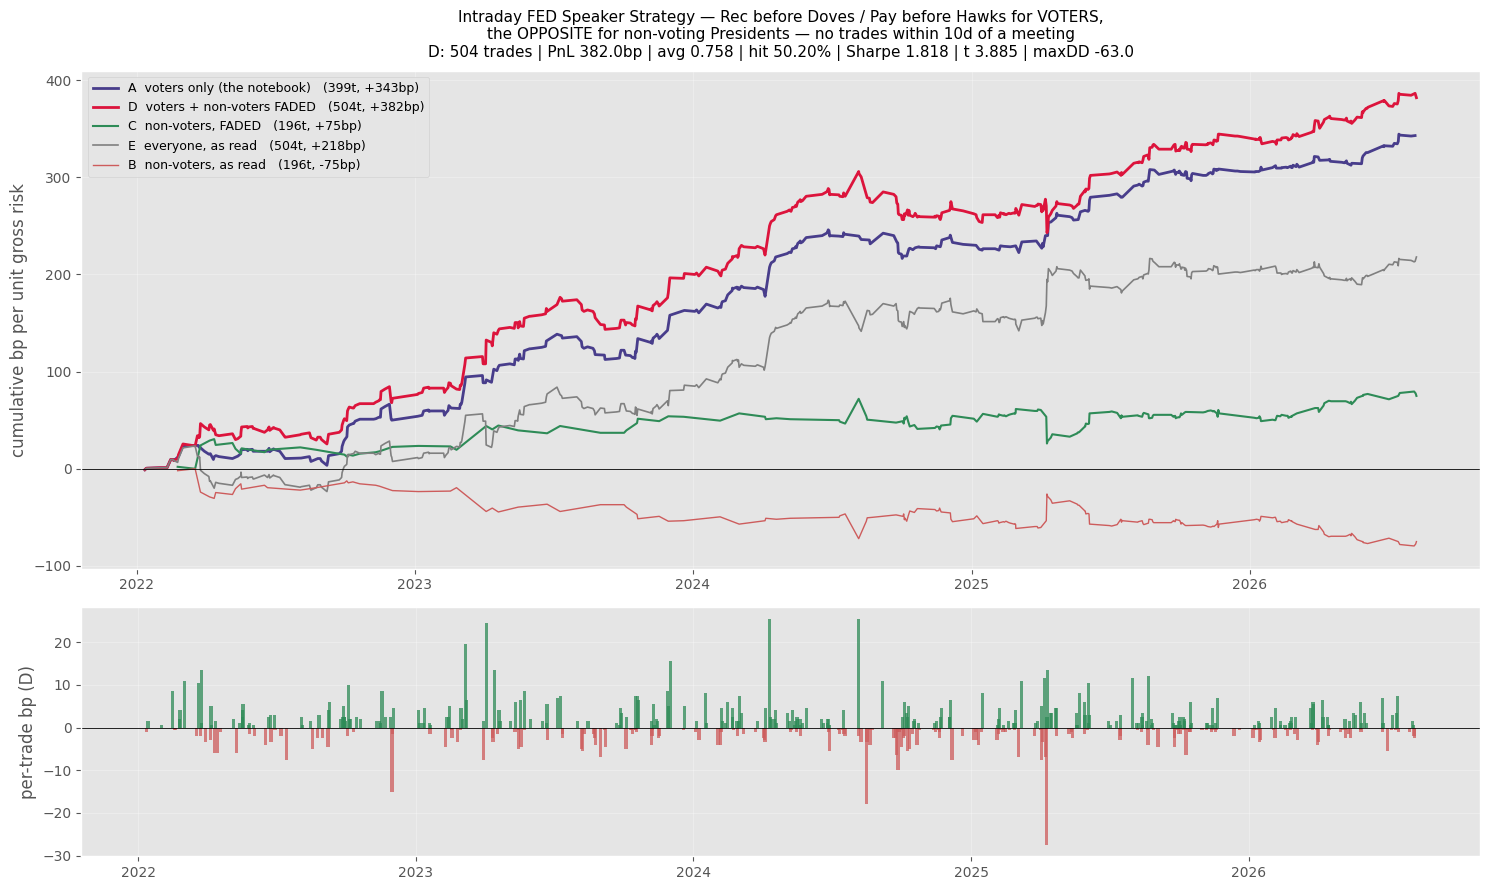

In [4]:
def perf(df, label):
    if df is None or df.empty:
        return {"book": label, "trades": 0}
    s, p = G.summarize(df), df.pnl_bp
    return {"book": label, "trades": s["trades"], "total_bp": round(s["total"], 2),
            "avg_bp": round(s["avg"], 4), "hit": round(s["hit_rate"], 4),
            "sharpe": round(s["sharpe"], 3),
            "sr_per_trade": round(p.mean() / p.std(ddof=1), 4),
            "t_stat": round(s["t_stat"], 3), "max_dd": round(s["max_dd"], 2),
            "tpy": round(s["trades_per_year"], 1)}

TBL = pd.DataFrame([perf(r.closed, k) for k, r in RES.items()]).set_index("book")
display(TBL)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
for nm, df, col, lw in [("A  voters only (the notebook)", A, "darkslateblue", 2.0),
                        ("D  voters + non-voters FADED", D, "crimson", 2.0),
                        ("C  non-voters, FADED", Cc, "seagreen", 1.5),
                        ("E  everyone, as read", E, "grey", 1.2),
                        ("B  non-voters, as read", B, "indianred", 1.0)]:
    ax.plot(df.opened_at.values, df.pnl_bp.cumsum().values, lw=lw, color=col,
            label=f"{nm}   ({len(df)}t, {df.pnl_bp.sum():+.0f}bp)")
ax.axhline(0, color="k", lw=.6); ax.legend(fontsize=9); ax.grid(alpha=.3)
ax.set_ylabel("cumulative bp per unit gross risk")
sD = G.summarize(D)
ax.set_title(
    "Intraday FED Speaker Strategy — Rec before Doves / Pay before Hawks for VOTERS,\n"
    "the OPPOSITE for non-voting Presidents — no trades within 10d of a meeting\n"
    f"D: {sD['trades']} trades | PnL {sD['total']:.1f}bp | avg {sD['avg']:.3f} | "
    f"hit {sD['hit_rate']:.2%} | Sharpe {sD['sharpe']:.3f} | t {sD['t_stat']:.3f} | "
    f"maxDD {sD['max_dd']:.1f}", fontsize=11, pad=10)

ax = axes[1]
w = (D.opened_at.max() - D.opened_at.min()) / min(len(D), 400)
ax.bar(D.opened_at.values, D.pnl_bp.values, width=w, alpha=.75,
       color=["seagreen" if v > 0 else "indianred" for v in D.pnl_bp])
ax.axhline(0, color="k", lw=.6); ax.grid(alpha=.3); ax.set_ylabel("per-trade bp (D)")
plt.tight_layout(); plt.show()

## 4. D is not A plus C

The one-position-at-a-time rule runs on the *combined* book, so letting the non-voters in does not
add trades to the voters' book — it competes with it. A non-voter position opened at T−60 and held
to T+240 sits in front of whatever speaks next, and the slot goes to whoever was first.

The funnel below is the combined book's. The displacement table is the part worth reading twice:
it is the price of the extra half of the roster, paid in voter speeches that never got traded.

It runs *both* ways, which is why the column arithmetic is
`standalone − displaced + freed = inside D` rather than a plain subtraction. An event that its own
single-class book dropped for overlapping a *same*-class predecessor can survive in the combined
book, because that predecessor was itself pre-empted by someone from the other half. Six trades
arrive that way; the effect is real but small, and it is shown rather than rounded away.

In [5]:
f_ = RES[COMB].funnel
row = {"raw events": f_["raw"]}
row.update({f"filtered: {k}": v for k, v in sorted(f_["filter_drops"].items(),
                                                   key=lambda x: -x[1])})
row["after filters"] = f_["after_filters"]
row.update({f"re-time: {k}": v for k, v in f_["retime_drops"].items() if v})
row["after overlap rule"] = f_["after_retime_overlap"]
for rk, reasons in f_["gate_reasons"].items():
    for k, v in sorted(reasons.items(), key=lambda x: -x[1]):
        row[f"gate rank {rk}: {k}"] = v
row["TRADEABLE"] = len(D)
display(pd.Series(row).to_frame("D  voters + non-voters FADED"))

d_v, d_n = D[D.is_voter == True], D[D.is_voter == False]
lost, lost_nv = A[~A.tag.isin(D.tag)], Cc[~Cc.tag.isin(D.tag)]
free, free_nv = d_v[~d_v.tag.isin(A.tag)], d_n[~d_n.tag.isin(Cc.tag)]
disp = pd.DataFrame([
    {"": "voter trades", "standalone book": len(A), "displaced": len(lost),
     "freed": len(free), "inside D": len(d_v),
     "displaced bp (as scored standalone)": round(lost.pnl_bp.sum(), 2),
     "freed bp (as scored in D)": round(free.pnl_bp.sum(), 2)},
    {"": "non-voter trades", "standalone book": len(Cc), "displaced": len(lost_nv),
     "freed": len(free_nv), "inside D": len(d_n),
     "displaced bp (as scored standalone)": round(lost_nv.pnl_bp.sum(), 2),
     "freed bp (as scored in D)": round(free_nv.pnl_bp.sum(), 2)},
]).set_index("")
display(disp)
assert (disp["standalone book"] - disp["displaced"] + disp["freed"]
        == disp["inside D"]).all(), "the displacement ledger does not close"
print(f"ledger closes: {len(A)} - {len(lost)} + {len(free)} = {len(d_v)} voter, "
      f"{len(Cc)} - {len(lost_nv)} + {len(free_nv)} = {len(d_n)} non-voter, "
      f"{len(d_v)} + {len(d_n)} = {len(D)}")

print(f"naive A + C would read {A.pnl_bp.sum() + Cc.pnl_bp.sum():+.2f}bp")
print(f"D actually books       {D.pnl_bp.sum():+.2f}bp")
print(f"the difference         {D.pnl_bp.sum() - A.pnl_bp.sum() - Cc.pnl_bp.sum():+.2f}bp "
      f"is the overlap rule, not a modelling choice")

,D voters + non-voters FADED
raw events,1164
filtered: before_start,324
filtered: too_close_to_fomc,15
after filters,825
re-time: overlap,315
after overlap rule,510
gate rank 3: no_bars_that_day,5
gate rank 3: stale_quote,1
TRADEABLE,504


,standalone book,displaced,freed,inside D,displaced bp (as scored standalone),freed bp (as scored in D)
,,,,,,
voter trades,399,52,2,349,41.5,-1.5
non-voter trades,196,45,4,155,-6.5,0.5


ledger closes: 399 - 52 + 2 = 349 voter, 196 - 45 + 4 = 155 non-voter, 349 + 155 = 504
naive A + C would read +418.00bp
D actually books       +382.00bp
the difference         -36.00bp is the overlap rule, not a modelling choice


## 5. Inside the combined book

Split D by what it did with the speaker. The voter half is the notebook's strategy, minus the
speeches it lost to a non-voter's position; the non-voter half is the new bet.

,trades,total_bp,avg_bp,hit,sharpe,sr_per_trade,t_stat,max_dd,tpy
book,,,,,,,,,
"voters, as read",349,300.0,0.8596,0.4986,1.881,0.2151,4.019,-29.5,76.5
"non-voters, FADED",155,82.0,0.5290,0.5097,0.607,0.1028,1.279,-55.5,34.8
D total,504,382.0,0.7579,0.5020,1.818,0.1731,3.885,-63.0,110.4
"(A, for reference)",399,343.0,0.8596,0.5138,2.099,0.2245,4.484,-29.5,87.4


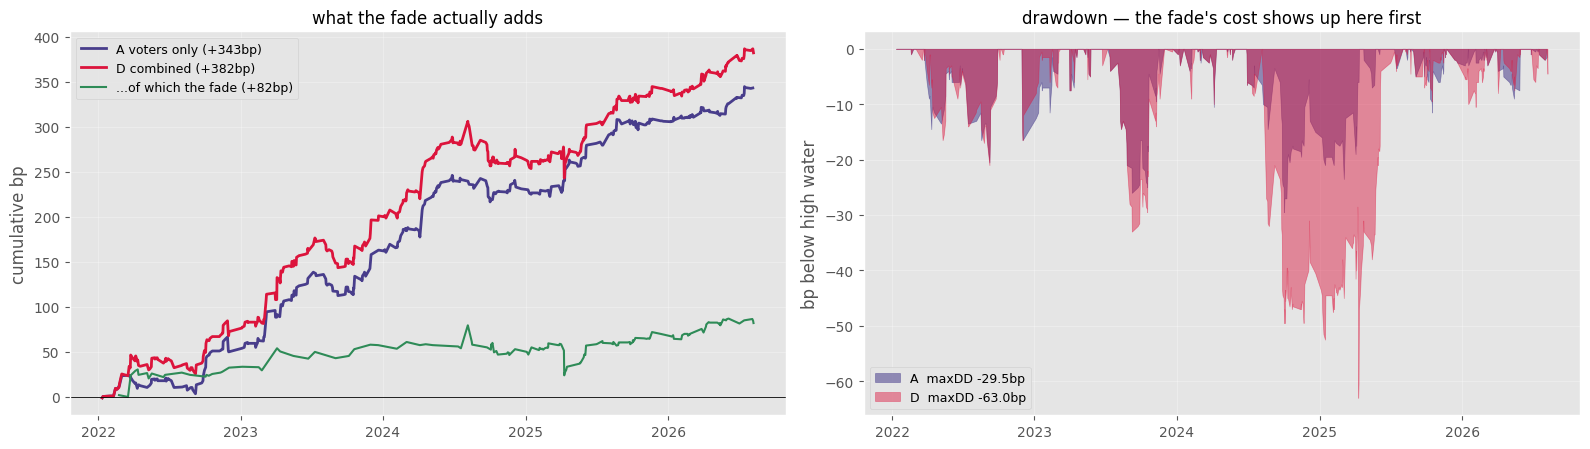

In [6]:
parts = pd.DataFrame([perf(d_v, "voters, as read"), perf(d_n, "non-voters, FADED"),
                      perf(D, "D total"), perf(A, "(A, for reference)")]).set_index("book")
display(parts)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
axes[0].plot(A.opened_at.values, A.pnl_bp.cumsum().values, lw=2,
             color="darkslateblue", label=f"A voters only ({A.pnl_bp.sum():+.0f}bp)")
axes[0].plot(D.opened_at.values, D.pnl_bp.cumsum().values, lw=2, color="crimson",
             label=f"D combined ({D.pnl_bp.sum():+.0f}bp)")
axes[0].plot(d_n.opened_at.values, d_n.pnl_bp.cumsum().values, lw=1.5, color="seagreen",
             label=f"...of which the fade ({d_n.pnl_bp.sum():+.0f}bp)")
axes[0].axhline(0, color="k", lw=.6); axes[0].legend(fontsize=9); axes[0].grid(alpha=.3)
axes[0].set_title("what the fade actually adds"); axes[0].set_ylabel("cumulative bp")

dd = lambda df: (df.pnl_bp.cumsum() - df.pnl_bp.cumsum().cummax())
axes[1].fill_between(A.opened_at.values, dd(A).values, 0, color="darkslateblue",
                     alpha=.55, label=f"A  maxDD {dd(A).min():.1f}bp")
axes[1].fill_between(D.opened_at.values, dd(D).values, 0, color="crimson",
                     alpha=.45, label=f"D  maxDD {dd(D).min():.1f}bp")
axes[1].legend(fontsize=9); axes[1].grid(alpha=.3)
axes[1].set_title("drawdown — the fade's cost shows up here first")
axes[1].set_ylabel("bp below high water")
plt.tight_layout(); plt.show()

## 6. The thesis predicts **zero**, and zero is what a fade cannot monetise

"The market does not care what a non-voter says" is a claim about *drift*: it says a non-voter's
speech is followed by nothing. A book of nothing pays nothing and loses its costs. For the fade to
be worth doing, the market must not merely ignore these speakers — it must move *against* them,
systematically.

So the question is not whether B is negative. It is whether B is negative by more than noise.

,trades,avg_bp,s.e.,t,boot 95% CI on avg,boot P(sign holds),sign-flip p (its own direction)
book,,,,,,,
"B non-voters, as read",196,-0.3827,0.3363,-1.138,"[-1.046, +0.273]",0.8751,0.1331
"C non-voters, FADED",196,0.3827,0.3363,1.138,"[-0.273, +1.046]",0.8751,0.1331
A voters only,399,0.8596,0.1917,4.484,NaN,NaN,0.0000
D combined,504,0.7579,0.1951,3.885,NaN,NaN,0.0000


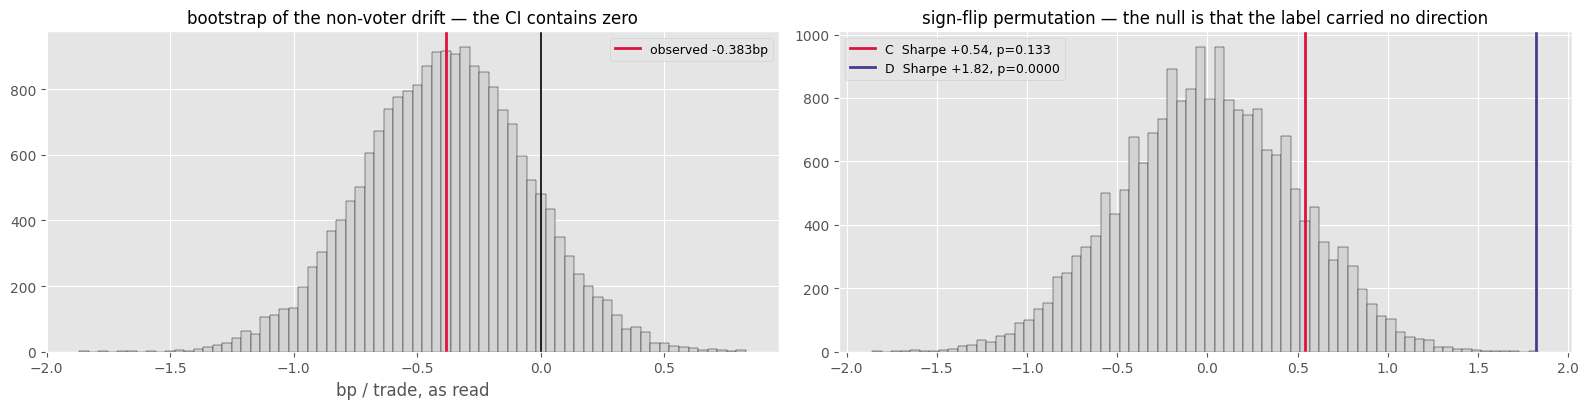

In [7]:
p = B.pnl_bp.to_numpy(float)
se = p.std(ddof=1) / np.sqrt(len(p))
rng = np.random.default_rng(20260812)
boot = np.array([rng.choice(p, size=len(p), replace=True).mean() for _ in range(20000)])
lo, hi = np.percentile(boot, [2.5, 97.5])

sfB = G.sign_flip_permutation(B, n_perm=20000)     # p is one-sided, P(perm >= realised)
sfC = G.sign_flip_permutation(Cc, n_perm=20000)
sfD = G.sign_flip_permutation(D, n_perm=20000)
sfA = G.sign_flip_permutation(A, n_perm=20000)

display(pd.DataFrame([
    {"book": "B non-voters, as read", "trades": len(p), "avg_bp": round(p.mean(), 4),
     "s.e.": round(se, 4), "t": round(p.mean() / se, 3),
     "boot 95% CI on avg": f"[{lo:+.3f}, {hi:+.3f}]",
     "boot P(sign holds)": round((boot < 0).mean(), 4),
     "sign-flip p (its own direction)": round(1 - sfB["p_value"], 4)},
    {"book": "C non-voters, FADED", "trades": len(p), "avg_bp": round(-p.mean(), 4),
     "s.e.": round(se, 4), "t": round(-p.mean() / se, 3),
     "boot 95% CI on avg": f"[{-hi:+.3f}, {-lo:+.3f}]",
     "boot P(sign holds)": round((boot < 0).mean(), 4),
     "sign-flip p (its own direction)": round(sfC["p_value"], 4)},
    {"book": "A voters only", "trades": len(A), "avg_bp": round(A.pnl_bp.mean(), 4),
     "s.e.": round(A.pnl_bp.std(ddof=1) / np.sqrt(len(A)), 4),
     "t": round(G.summarize(A)["t_stat"], 3),
     "sign-flip p (its own direction)": round(sfA["p_value"], 4)},
    {"book": "D combined", "trades": len(D), "avg_bp": round(D.pnl_bp.mean(), 4),
     "s.e.": round(D.pnl_bp.std(ddof=1) / np.sqrt(len(D)), 4),
     "t": round(G.summarize(D)["t_stat"], 3),
     "sign-flip p (its own direction)": round(sfD["p_value"], 4)},
]).set_index("book"))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.2))
axes[0].hist(boot, bins=70, color="lightgrey", edgecolor="k", lw=.3)
axes[0].axvline(0, color="k", lw=1.2)
axes[0].axvline(p.mean(), color="crimson", lw=2, label=f"observed {p.mean():+.3f}bp")
axes[0].set_title("bootstrap of the non-voter drift — the CI contains zero")
axes[0].set_xlabel("bp / trade, as read"); axes[0].legend(fontsize=9)
axes[1].hist(sfC["perm"], bins=70, color="lightgrey", edgecolor="k", lw=.3)
axes[1].axvline(sfC["realized_sharpe"], color="crimson", lw=2,
                label=f"C  Sharpe {sfC['realized_sharpe']:+.2f}, p={sfC['p_value']:.3f}")
axes[1].axvline(sfD["realized_sharpe"], color="darkslateblue", lw=2,
                label=f"D  Sharpe {sfD['realized_sharpe']:+.2f}, p={sfD['p_value']:.4f}")
axes[1].set_title("sign-flip permutation — the null is that the label carried no direction")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 7. Is "no vote" a real seam, or one of many ways to cut 155 trades?

The fade turns 155 of the whole book's 504 trades upside down. Any partition of that size would
change the total; the question is whether *this* partition is special. So: flip a random 155 of the
504 twenty thousand times and ask where the real one lands.

This is the sharpest test in the notebook, because it holds the book, the instrument, the window
and the trade count fixed and varies only *which* trades get the minus sign.

Read what it does and does not say. It tests the **gap** between the two halves of the roster, not
the **level** of either. The non-voters can sit far below the book's average while still being
indistinguishable from zero in their own right — and §6 is where that second question is answered.
The cell prints both so the difference is not left to the reader.

flipping the 155 non-voter trades : +382.00bp
flipping a random 155 of 504   : +84.51 +- 91.61bp
the non-voter partition beats 99.9% of random ones   one-sided p = 0.0006

what that p-value is made of — the GAP, not the level:
  voters, as read     +0.8596 bp/trade   (349 trades)
  non-voters, as read -0.5290 bp/trade   (155 trades)
  gap                 +1.3886 bp/trade
  and the non-voter level on its own is -0.5290 +- 0.4135 — see section 6



counterfactual — non-voter drift set to EXACTLY zero, same test: p = 0.0217
it still rejects, because a book where one half has drift and the other has none is
a real seam. That is the claim this test supports, and it is not the claim that the
fade makes money.


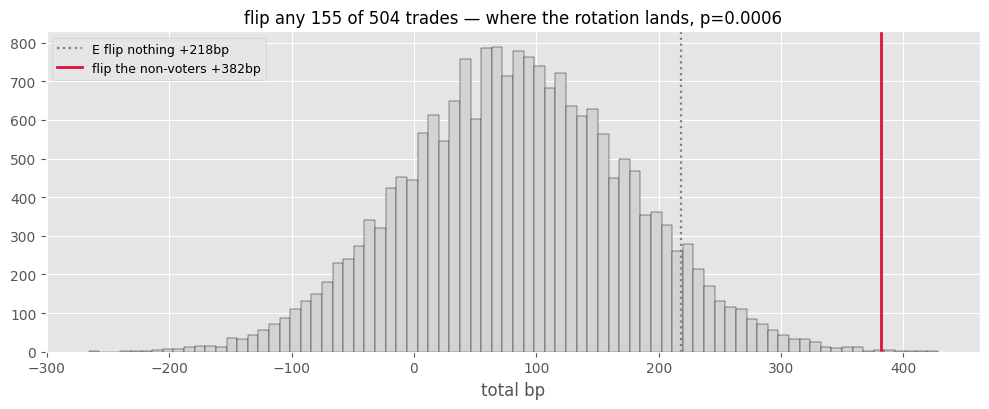

In [8]:
Es = E.sort_values(["opened_at", "tag"]).reset_index(drop=True)
isnv = (Es.is_voter == False).to_numpy()
pe = Es.pnl_bp.to_numpy(float)
k = int(isnv.sum())
real = pe.sum() - 2 * pe[isnv].sum()

rng2 = np.random.default_rng(11)
idx = np.arange(len(pe))
draws = np.array([pe.sum() - 2 * pe[rng2.choice(idx, size=k, replace=False)].sum()
                  for _ in range(20000)])
pval = float((draws >= real).mean())

print(f"flipping the {k} non-voter trades : {real:+.2f}bp")
print(f"flipping a random {k} of {len(pe)}   : {draws.mean():+.2f} +- {draws.std():.2f}bp")
print(f"the non-voter partition beats {1 - pval:.1%} of random ones   one-sided p = {pval:.4f}")
print()
print("what that p-value is made of — the GAP, not the level:")
print(f"  voters, as read     {pe[~isnv].mean():+.4f} bp/trade   ({int((~isnv).sum())} trades)")
print(f"  non-voters, as read {pe[isnv].mean():+.4f} bp/trade   ({k} trades)")
print(f"  gap                 {pe[~isnv].mean() - pe[isnv].mean():+.4f} bp/trade")
print(f"  and the non-voter level on its own is {pe[isnv].mean():+.4f} "
      f"+- {pe[isnv].std(ddof=1)/np.sqrt(k):.4f} — see section 6")

# How much of that p-value would survive if the fade were worth exactly nothing?
# Demean the non-voter rows so their drift is identically zero, and re-run the SAME test.
pz = pe.copy()
pz[isnv] = pz[isnv] - pz[isnv].mean()
rng4 = np.random.default_rng(11)
real_z = pz.sum() - 2 * pz[isnv].sum()
draws_z = np.array([pz.sum() - 2 * pz[rng4.choice(idx, size=k, replace=False)].sum()
                    for _ in range(20000)])
print(f"\ncounterfactual — non-voter drift set to EXACTLY zero, same test: "
      f"p = {float((draws_z >= real_z).mean()):.4f}")
print("it still rejects, because a book where one half has drift and the other has none is")
print("a real seam. That is the claim this test supports, and it is not the claim that the")
print("fade makes money.")

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.hist(draws, bins=80, color="lightgrey", edgecolor="k", lw=.3)
ax.axvline(E.pnl_bp.sum(), color="grey", lw=1.6, ls=":",
           label=f"E flip nothing {E.pnl_bp.sum():+.0f}bp")
ax.axvline(real, color="crimson", lw=2, label=f"flip the non-voters {real:+.0f}bp")
ax.set_title(f"flip any {k} of {len(pe)} trades — where the rotation lands, p={pval:.4f}")
ax.set_xlabel("total bp"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 8. Who is the fade actually short?

A book of 196 trades across 13 speakers is not a market-wide behaviour if three of them carry it.
The column is the drift **as read** — negative means the fade pays.

Concentration is easy to point at and easy to over-read, so the cell also computes what
concentration a book of this size and this shape produces *by chance*: shuffle the 196 P&Ls across
the same 13 group sizes and look at the worst three. If the observed figure sits inside that
distribution, "three people carry it" is a description of arithmetic, not a finding.

,trades,total_bp_as_read,avg_bp_as_read,district
speaker,,,,
Goolsbee,23,-40.0,-1.739,Chicago
Bostic,32,-31.0,-0.969,Atlanta
Mester,11,-26.5,-2.409,Cleveland
Hammack,8,-13.0,-1.625,Cleveland
Daly,21,-4.5,-0.214,San Francisco
Harker,8,-3.0,-0.375,Philadelphia
Collins,1,-1.5,-1.500,Boston
Schmid,9,-1.0,-0.111,Kansas City
Paulson,2,2.5,1.250,Philadelphia


the three biggest contributors are ['Goolsbee', 'Bostic', 'Mester']: -97.5bp of the book's -75.0bp, on 66 of 196 trades
the other 10 non-voters are +22.5bp as read — i.e. the fade LOSES on them



null (same 13 group sizes, P&L reshuffled, 20k draws): worst three sum -88.58 +- 17.98bp
observed -97.5bp   ->   P(null at least this concentrated) = 0.2969
so the concentration is ORDINARY for a book this size: it is not evidence against the
fade, it is what a near-zero book with 13 unequal groups looks like.


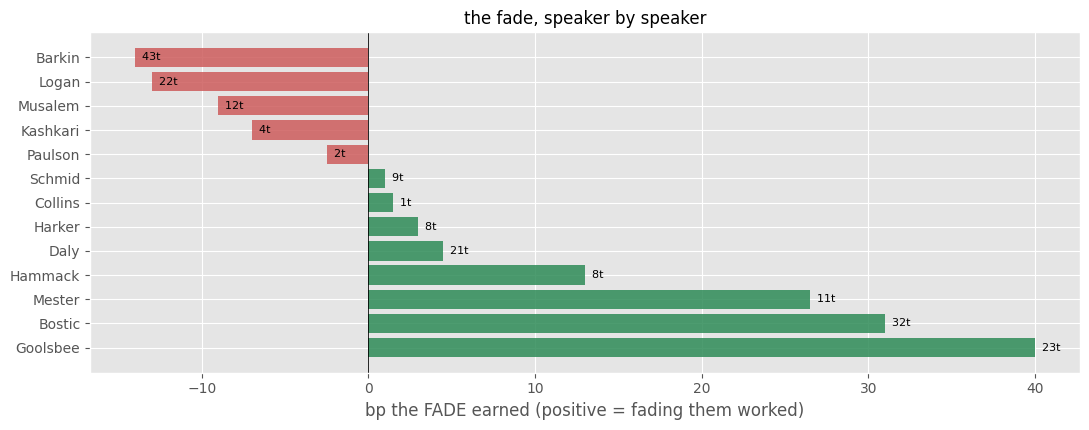

In [9]:
spk = (B.groupby("speaker").pnl_bp.agg(["count", "sum", "mean"])
       .rename(columns={"count": "trades", "sum": "total_bp_as_read",
                        "mean": "avg_bp_as_read"}).sort_values("total_bp_as_read"))
spk["district"] = [FX.DISTRICT.get(s, "-") for s in spk.index]
display(spk.round(3))

top3 = spk.head(3)
print(f"the three biggest contributors are {list(top3.index)}: "
      f"{top3.total_bp_as_read.sum():+.1f}bp of the book's {B.pnl_bp.sum():+.1f}bp, "
      f"on {int(top3.trades.sum())} of {len(B)} trades")
print(f"the other {len(spk) - 3} non-voters are {spk.iloc[3:].total_bp_as_read.sum():+.1f}bp "
      f"as read — i.e. the fade LOSES on them")

# ...and what that looks like under random assignment, same group sizes.
sizes = spk.trades.to_numpy()
pv = B.pnl_bp.to_numpy(float)
rng3 = np.random.default_rng(7)
worst3 = np.empty(20000)
for i in range(20000):
    sh = rng3.permutation(pv)
    sums = np.add.reduceat(sh, np.concatenate([[0], np.cumsum(sizes)[:-1]]))
    worst3[i] = np.sort(sums)[:3].sum()
obs3 = top3.total_bp_as_read.sum()
p_conc = float((worst3 <= obs3).mean())
print(f"\nnull (same 13 group sizes, P&L reshuffled, 20k draws): worst three sum "
      f"{worst3.mean():+.2f} +- {worst3.std():.2f}bp")
print(f"observed {obs3:+.1f}bp   ->   P(null at least this concentrated) = {p_conc:.4f}")
print("so the concentration is ORDINARY for a book this size: it is not evidence against the")
print("fade, it is what a near-zero book with 13 unequal groups looks like.")

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.barh(spk.index, -spk.total_bp_as_read,
        color=["seagreen" if v < 0 else "indianred" for v in spk.total_bp_as_read], alpha=.85)
ax.axvline(0, color="k", lw=.6)
ax.set_xlabel("bp the FADE earned (positive = fading them worked)")
ax.set_title("the fade, speaker by speaker")
for i, (nm, r) in enumerate(spk.iterrows()):
    ax.text(-r.total_bp_as_read, i, f"  {int(r.trades)}t", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 9. Through time

The non-voter roster turns over every year by construction — the rotation is the point — so a fade
that worked on one cohort is not the same trade as one that works on the next.

,A voters (bp),C non-voters FADED (bp),C trades,C bp/trade,D combined (bp)
year,,,,,
2022,50.0,22.5,23,0.978,72.5
2023,113.0,31.0,17,1.824,128.5
2024,68.0,1.0,31,0.032,64.5
2025,75.0,0.5,80,0.006,76.5
2026,37.0,20.0,45,0.444,40.0


trades  total_bp  avg_bp  sharpe  \
book               half                                         
A voters           1st half     199     232.5  1.1683   2.525   
                   2nd half     200     110.5  0.5525   1.578   
C non-voters FADED 1st half      98      36.5  0.3724   0.331   
                   2nd half      98      38.5  0.3929   1.413   
D combined         1st half     252     272.5  1.0813   2.106   
                   2nd half     252     109.5  0.4345   1.368   

                                                range  
book               half                                
A voters           1st half  2022-01-11 -> 2024-05-21  
                   2nd half  2024-05-23 -> 2026-08-05  
C non-voters FADED 1st half  2022-02-23 -> 2025-05-19  
                   2nd half  2025-05-19 -> 2026-08-07  
D combined         1st half  2022-01-11 -> 2024-09-25  
                   2nd half  2024-09-26 -> 2026-08-07

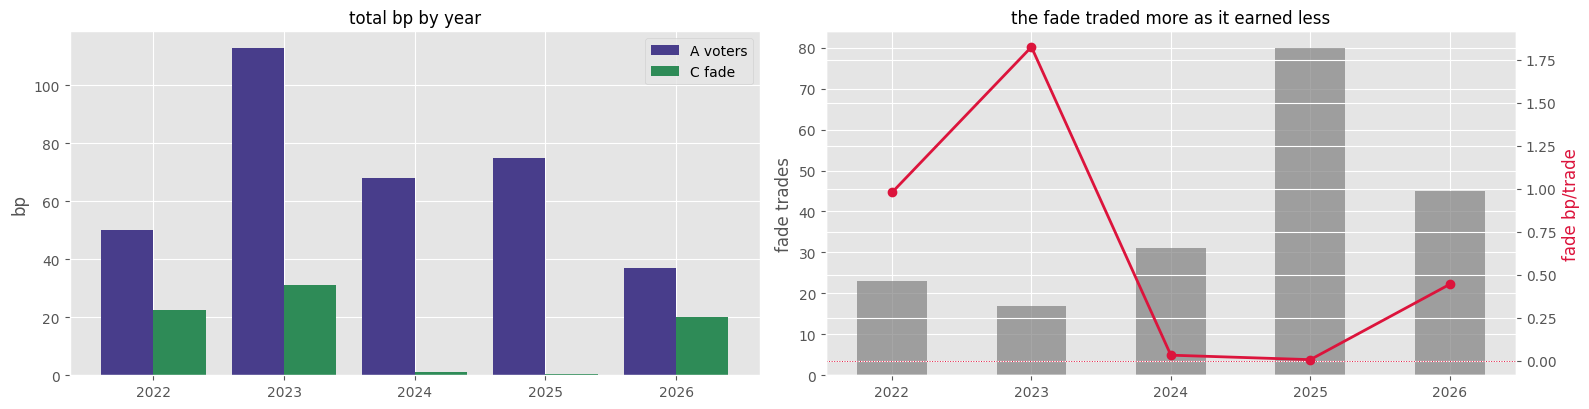

In [10]:
yr = pd.DataFrame({
    "A voters (bp)": A.groupby("year").pnl_bp.sum(),
    "C non-voters FADED (bp)": Cc.groupby("year").pnl_bp.sum(),
    "C trades": Cc.groupby("year").pnl_bp.count(),
    "C bp/trade": Cc.groupby("year").pnl_bp.mean(),
    "D combined (bp)": D.groupby("year").pnl_bp.sum(),
}).round(3)
display(yr)

halves = []
for nm, df in [("A voters", A), ("C non-voters FADED", Cc), ("D combined", D)]:
    mid = len(df) // 2
    for lbl, sub in [("1st half", df.iloc[:mid]), ("2nd half", df.iloc[mid:])]:
        s = G.summarize(sub)
        halves.append({"book": nm, "half": lbl, "trades": s["trades"],
                       "total_bp": round(s["total"], 2), "avg_bp": round(s["avg"], 4),
                       "sharpe": round(s["sharpe"], 3),
                       "range": f"{s['first'].date()} -> {s['last'].date()}"})
display(pd.DataFrame(halves).set_index(["book", "half"]))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.2))
x = np.arange(len(yr))
axes[0].bar(x - .2, yr["A voters (bp)"].values, .4, label="A voters", color="darkslateblue")
axes[0].bar(x + .2, yr["C non-voters FADED (bp)"].values, .4, label="C fade",
            color="seagreen")
axes[0].set_xticks(x); axes[0].set_xticklabels(yr.index.astype(str))
axes[0].axhline(0, color="k", lw=.6); axes[0].legend(); axes[0].set_ylabel("bp")
axes[0].set_title("total bp by year")
axes[1].bar(x, yr["C trades"].values, .5, color="grey", alpha=.7)
ax2 = axes[1].twinx()
ax2.plot(x, yr["C bp/trade"].values, marker="o", color="crimson", lw=2)
ax2.axhline(0, color="crimson", lw=.7, ls=":")
axes[1].set_xticks(x); axes[1].set_xticklabels(yr.index.astype(str))
axes[1].set_ylabel("fade trades"); ax2.set_ylabel("fade bp/trade", color="crimson")
axes[1].set_title("the fade traded more as it earned less")
plt.tight_layout(); plt.show()

## 10. Costs

`cost_bp` is charged per trade, per unit of gross risk, so a book that trades more pays more in
total even at the same edge. D trades 26% more often than A on a thinner average edge — which is
exactly the shape that loses a comparison as soon as the cost is not zero.

The number to find below is the round trip at which D stops being better than A. For scale: an SR3
outright quotes one tick wide, and a tick on a deferred contract is 0.5 bp — so **crossing the
spread in and out is on the order of 0.5 bp round trip**, before any market impact. That is above
the crossover, and it is the honest place to read this table from.

,A voters only (the notebook),"B non-voters, as read","C non-voters, FADED",D voters + non-voters FADED,"E everyone, as read",F voters FADED + non-voters as read
cost_bp_rt,,,,,,
0.000,343.0,-75.0,75.0,382.0,218.0,-382.0
0.125,293.1,-99.5,50.5,319.0,155.0,-445.0
0.250,243.3,-124.0,26.0,256.0,92.0,-508.0
0.375,193.4,-148.5,1.5,193.0,29.0,-571.0
0.500,143.5,-173.0,-23.0,130.0,-34.0,-634.0
0.750,43.8,-222.0,-72.0,4.0,-160.0,-760.0
1.000,-56.0,-271.0,-121.0,-122.0,-286.0,-886.0


,break-even round trip (bp/trade)
A voters only (the notebook),0.8596
"B non-voters, as read",-0.3827
"C non-voters, FADED",0.3827
D voters + non-voters FADED,0.7579
"E everyone, as read",0.4325
F voters FADED + non-voters as read,-0.7579


D and A are equal at a round trip of 0.3714bp (+39.0bp of extra gross bought with 105 extra trades)
below that the fade is worth having; above it, it is not.
for reference the whole book's own break-even is 0.7579bp


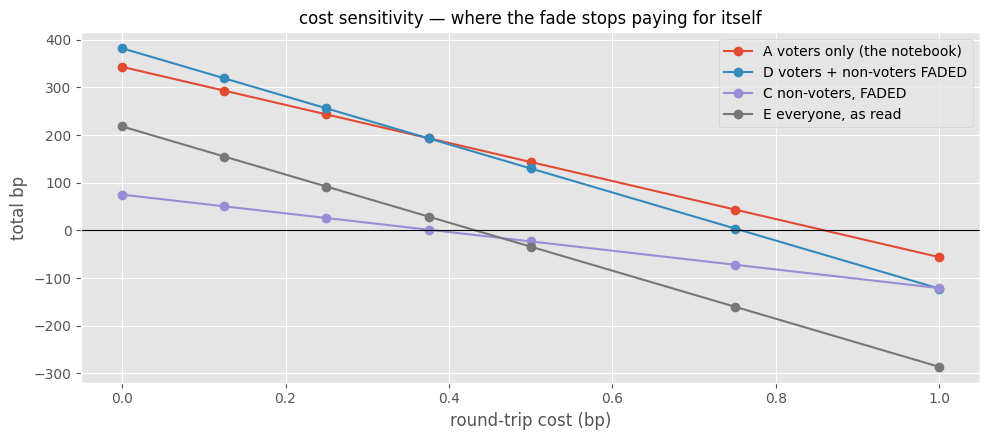

In [11]:
COSTS = [0.0, 0.125, 0.25, 0.375, 0.5, 0.75, 1.0]
cost_df = pd.DataFrame([{"cost_bp_rt": c,
                         **{k: round(r.closed.pnl_bp_gross.sum() - c * len(r.closed), 1)
                            for k, r in RES.items()}} for c in COSTS]).set_index("cost_bp_rt")
display(cost_df)

be = pd.Series({k: r.closed.pnl_bp_gross.mean() for k, r in RES.items()},
               name="break-even round trip (bp/trade)").round(4)
display(be.to_frame())

# Both books are linear in the cost, so the crossover is exact, not a grid cell:
#   D_total(c) - A_total(c) = (gross_D - gross_A) - c * (n_D - n_A) = 0
xover = ((D.pnl_bp_gross.sum() - A.pnl_bp_gross.sum()) / (len(D) - len(A)))
print(f"D and A are equal at a round trip of {xover:.4f}bp "
      f"(+{D.pnl_bp_gross.sum() - A.pnl_bp_gross.sum():.1f}bp of extra gross bought with "
      f"{len(D) - len(A)} extra trades)")
print(f"below that the fade is worth having; above it, it is not.")
print(f"for reference the whole book's own break-even is {D.pnl_bp_gross.mean():.4f}bp")

fig, ax = plt.subplots(figsize=(10, 4.5))
cost_df[[HEAD, COMB, "C non-voters, FADED", "E everyone, as read"]].plot(marker="o", ax=ax)
ax.axhline(0, color="k", lw=.8); ax.set_ylabel("total bp"); ax.set_xlabel("round-trip cost (bp)")
ax.set_title("cost sensitivity — where the fade stops paying for itself")
plt.tight_layout(); plt.show()

## 11. Does the sign survive a change of instrument?

One number on one contract is an anecdote. The same book priced on every warm structure asks
whether the non-voter drift is a property of these speeches or of the 3rd SR3 contract. Read the
**sign** column, not the best cell: this is a robustness check, not a search.

warm ranks: [1, 2, 3, 4, 5, 6]   instruments priced: 22


,A_avg,A_t,nonvoter_avg_as_read,nonvoter_t,D_avg,D_t,D_sharpe,D_trades,A_sharpe
instrument,,,,,,,,,
OUT_1,0.2233,2.24,-0.1093,-0.62,0.1983,1.95,0.911,508,1.050
OUT_2,0.6393,4.21,-0.2700,-1.01,0.5492,3.53,1.651,508,1.972
OUT_3,0.8596,4.48,-0.3827,-1.14,0.7579,3.89,1.818,504,2.099
OUT_4,0.8570,3.93,-0.5075,-1.37,0.7864,3.59,1.681,508,1.840
OUT_5,0.8284,3.51,-0.5700,-1.50,0.7864,3.39,1.587,508,1.643
OUT_6,0.7531,3.16,-0.5905,-1.56,0.7461,3.21,1.501,508,1.481
SPR_1_2,0.2060,4.80,-0.0823,-1.32,0.1733,4.30,2.010,507,2.246
SPR_2_3,0.1162,3.78,-0.0765,-1.60,0.1118,3.85,1.804,503,1.769
SPR_3_4,-0.0000,-0.00,-0.0357,-0.95,0.0114,0.49,0.228,503,-0.000


non-voter drift is negative on 21/22 instruments — consistent
...and reaches |t| > 2 on 0/22 — never
D has a higher Sharpe than A on 8/22

common events across all instruments: 194
effective independent dimensions among the 22 instruments: 2.58 (first eigenvalue carries 57.9%)
so 21/22 is worth about two independent observations, not twenty-two — it says the
result is not an artefact of picking OUT_3, and nothing more than that.

D's Sharpe beats A's on 8; D's edge PER TRADE beats A's on 6: ['SPR_3_4', 'SPR_4_5', 'SPR_5_6', 'SPR_2_4', 'SPR_3_5', 'SPR_4_6']
the difference is annualisation — on ['OUT_6', 'SPR_2_3'] D scores higher while earning less per trade


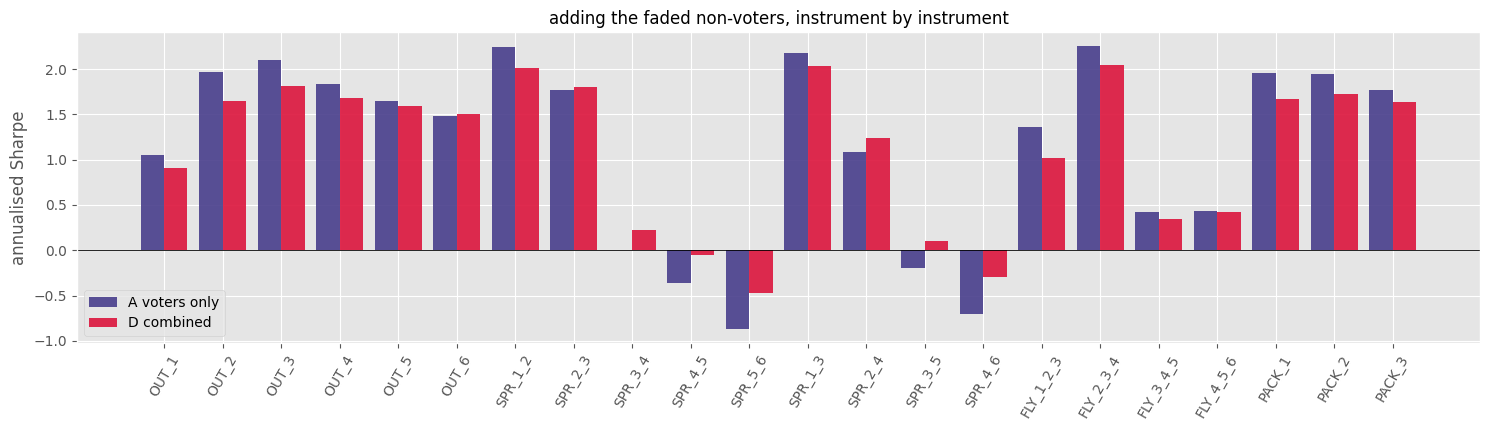

In [12]:
_cfgF = G.CB_CONFIGS["FED"]
_timed, _ = HC.retime(HC.apply_filters(RAW, BOOKS[COMB]["filters"])[0], _cfgF, -60, 240, False)
WARM = [r for r in range(1, 9) if HC.check_coverage(_timed, _cfgF, [r])["ok"]]
_cat = HC.catalogue(max(WARM))
INSTRUMENTS = ([{"kind": "outright", "rank": r} for r in WARM] +
               [{"structure": s.name} for s in _cat.values()
                if s.kind != "outright" and set(s.ranks) <= set(WARM)])
print(f"warm ranks: {WARM}   instruments priced: {len(INSTRUMENTS)}")

rows, SWEEP, NV_SERIES = [], {}, {}
for i in INSTRUMENTS:
    nm = i.get("structure") or f"OUT_{i['rank']}"
    ra = HC.run_config(cfg(nm, instrument=i), RAW, MDP).closed
    rb = HC.run_config(cfg(nm, filters={"voters": "nonvoters"}, instrument=i),
                       RAW, MDP).closed
    rd = HC.run_config(cfg(nm, filters={"voters": "all"}, flip="nonvoters",
                           instrument=i), RAW, MDP).closed
    SWEEP[f"A:{nm}"] = ra.pnl_bp.to_numpy(float)
    SWEEP[f"D:{nm}"] = rd.pnl_bp.to_numpy(float)
    NV_SERIES[nm] = rb.set_index("tag").pnl_bp
    rows.append({"instrument": nm,
                 "A_avg": round(ra.pnl_bp.mean(), 4), "A_t": round(G.summarize(ra)["t_stat"], 2),
                 "nonvoter_avg_as_read": round(rb.pnl_bp.mean(), 4),
                 "nonvoter_t": round(G.summarize(rb)["t_stat"], 2),
                 "D_avg": round(rd.pnl_bp.mean(), 4), "D_t": round(G.summarize(rd)["t_stat"], 2),
                 "D_sharpe": round(G.summarize(rd)["sharpe"], 3), "D_trades": len(rd),
                 "A_sharpe": round(G.summarize(ra)["sharpe"], 3)})
INST = pd.DataFrame(rows).set_index("instrument")
display(INST)

neg = int((INST.nonvoter_avg_as_read < 0).sum())
sig = int((INST.nonvoter_t.abs() > 2).sum())
better = int((INST.D_sharpe > INST.A_sharpe).sum())
print(f"non-voter drift is negative on {neg}/{len(INST)} instruments — consistent")
print(f"...and reaches |t| > 2 on {sig}/{len(INST)} — never")
print(f"D has a higher Sharpe than A on {better}/{len(INST)}")

# 22 instruments is not 22 observations. They re-price the SAME ~196 events, and the
# legs are nested, so count how many independent directions there actually are:
# the participation ratio of the correlation matrix's eigenvalues.
NVP = pd.DataFrame(NV_SERIES).dropna(how="any")
Cmat = np.corrcoef(NVP.to_numpy(float).T)
ev = np.linalg.eigvalsh(Cmat)
eff = float(ev.sum() ** 2 / (ev ** 2).sum())
print(f"\ncommon events across all instruments: {len(NVP)}")
print(f"effective independent dimensions among the {len(INST)} instruments: {eff:.2f} "
      f"(first eigenvalue carries {ev.max() / ev.sum():.1%})")
print("so 21/22 is worth about two independent observations, not twenty-two — it says the")
print("result is not an artefact of picking OUT_3, and nothing more than that.")

# where the fade genuinely helped: Sharpe is annualised by trade count, so a book that
# trades more can score higher on a THINNER edge. Separate the two.
INST["D_edge_up"] = INST.D_avg > INST.A_avg
print(f"\nD's Sharpe beats A's on {better}; D's edge PER TRADE beats A's on "
      f"{int(INST.D_edge_up.sum())}: {list(INST.index[INST.D_edge_up])}")
print(f"the difference is annualisation — on {list(INST.index[(INST.D_sharpe > INST.A_sharpe) & ~INST.D_edge_up])} "
      f"D scores higher while earning less per trade")

fig, ax = plt.subplots(figsize=(15, 4.4))
x = np.arange(len(INST))
ax.bar(x - .2, INST.A_sharpe, .4, label="A voters only", color="darkslateblue", alpha=.9)
ax.bar(x + .2, INST.D_sharpe, .4, label="D combined", color="crimson", alpha=.9)
ax.set_xticks(x); ax.set_xticklabels(INST.index, rotation=60)
ax.axhline(0, color="k", lw=.6); ax.legend(); ax.set_ylabel("annualised Sharpe")
ax.set_title("adding the faded non-voters, instrument by instrument")
plt.tight_layout(); plt.show()

## 12. And a change of window?

Same question against entry and exit. The left panel is the non-voter drift **as read** — every
negative cell is a window in which the fade would have paid.

One thing that grid does not vary, and should be said out loud. A day-only event has no recorded
speech minute, so `retime_synthetic: False` leaves it trading the whole session in *every* cell —
its window is identical at T−15/T+30 and at T−120/T+240. Those events are a quarter of the
non-voter book and they carry most of its drift, so the sweep is less of a sweep than the 25 cells
suggest. The cell measures both, and re-runs the grid on the events whose window actually moves.

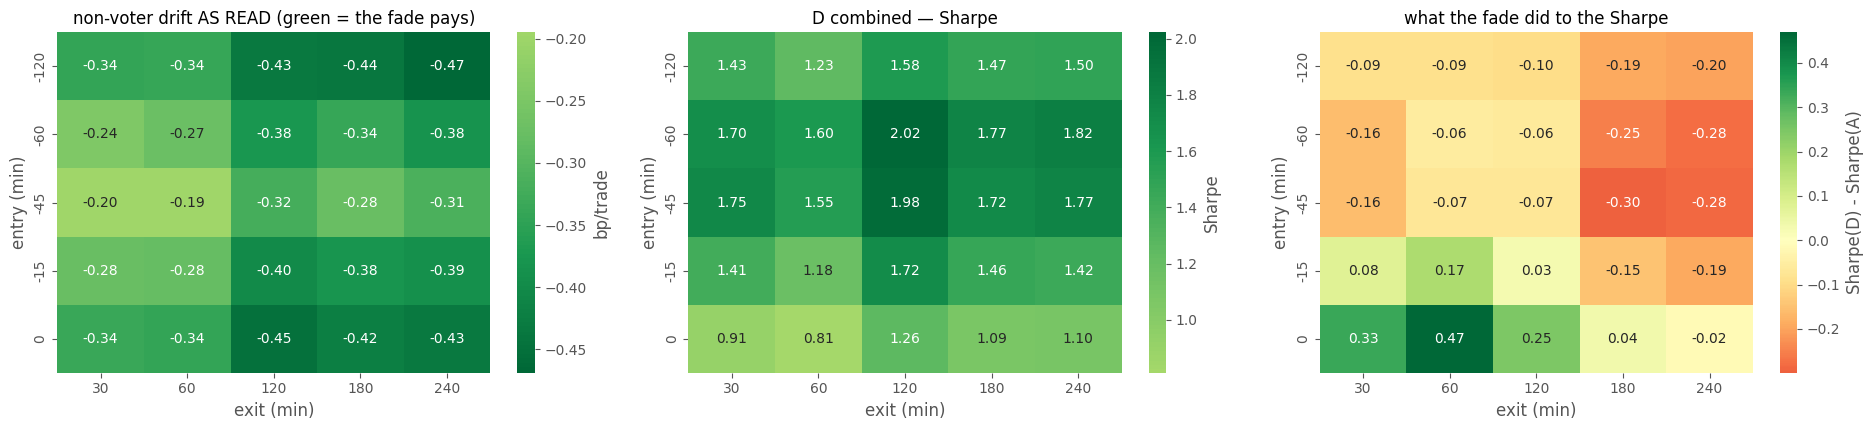

non-voter drift negative in 25/25 windows
D beats A on Sharpe in 7/25 windows

composition: 55 of 196 non-voter trades (28%) are day-only events on a fixed session window,
and they carry -52.5bp of the book's -75.0bp (70%). They do not move with the grid.
on the 141 trades whose window DOES move, the drift is -0.1596bp/trade and negative in 22/25 windows (positive in 3).


,trades,total_bp,avg_bp,hit,sharpe,sr_per_trade,t_stat,max_dd,tpy
book,,,,,,,,,
"B, timed speeches",141,-22.5,-0.1596,0.4255,-0.264,-0.0360,-0.428,-55.0,53.6
"B, day-only (session window)",55,-52.5,-0.9545,0.4182,-0.627,-0.1782,-1.321,-57.5,12.4
"B, all",196,-75.0,-0.3827,0.4235,-0.539,-0.0813,-1.138,-79.5,44.1


In [13]:
ENTRY, EXIT = [-120, -60, -45, -15, 0], [30, 60, 120, 180, 240]
g_nv = pd.DataFrame(index=ENTRY, columns=EXIT, dtype=float)
g_nvt = pd.DataFrame(index=ENTRY, columns=EXIT, dtype=float)   # timed speeches only
g_d = pd.DataFrame(index=ENTRY, columns=EXIT, dtype=float)
g_a = pd.DataFrame(index=ENTRY, columns=EXIT, dtype=float)
for e in ENTRY:
    for x in EXIT:
        t = {"entry_offset_min": e, "exit_offset_min": x}
        rb = HC.run_config(cfg("b", filters={"voters": "nonvoters"}, timing=t), RAW, MDP).closed
        rd = HC.run_config(cfg("d", filters={"voters": "all"}, flip="nonvoters", timing=t),
                           RAW, MDP).closed
        ra = HC.run_config(cfg("a", timing=t), RAW, MDP).closed
        g_nv.loc[e, x] = rb.pnl_bp.mean()
        g_nvt.loc[e, x] = rb[rb.timestamp_source == "forexfactory"].pnl_bp.mean()
        g_d.loc[e, x] = G.summarize(rd)["sharpe"]
        g_a.loc[e, x] = G.summarize(ra)["sharpe"]
        SWEEP[f"A:{e}|{x}"] = ra.pnl_bp.to_numpy(float)
        SWEEP[f"D:{e}|{x}"] = rd.pnl_bp.to_numpy(float)

fig, axes = plt.subplots(1, 3, figsize=(19, 4.4))
sns.heatmap(g_nv.astype(float), annot=True, fmt=".2f", cmap="RdYlGn_r", center=0, ax=axes[0],
            cbar_kws={"label": "bp/trade"})
axes[0].set_title("non-voter drift AS READ (green = the fade pays)")
sns.heatmap(g_d.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1],
            cbar_kws={"label": "Sharpe"})
axes[1].set_title("D combined — Sharpe")
sns.heatmap((g_d - g_a).astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            ax=axes[2], cbar_kws={"label": "Sharpe(D) - Sharpe(A)"})
axes[2].set_title("what the fade did to the Sharpe")
for a in axes:
    a.set_xlabel("exit (min)"); a.set_ylabel("entry (min)")
plt.tight_layout(); plt.show()

print(f"non-voter drift negative in {int((g_nv < 0).sum().sum())}/{g_nv.size} windows")
print(f"D beats A on Sharpe in {int(((g_d - g_a) > 0).sum().sum())}/{g_nv.size} windows")

b_syn = B[B.timestamp_source == "synthetic"]
b_ff = B[B.timestamp_source == "forexfactory"]
print(f"\ncomposition: {len(b_syn)} of {len(B)} non-voter trades ({len(b_syn)/len(B):.0%}) are "
      f"day-only events on a fixed session window,")
print(f"and they carry {b_syn.pnl_bp.sum():+.1f}bp of the book's {B.pnl_bp.sum():+.1f}bp "
      f"({b_syn.pnl_bp.sum()/B.pnl_bp.sum():.0%}). They do not move with the grid.")
print(f"on the {len(b_ff)} trades whose window DOES move, the drift is "
      f"{b_ff.pnl_bp.mean():+.4f}bp/trade and negative in "
      f"{int((g_nvt < 0).sum().sum())}/{g_nvt.size} windows "
      f"(positive in {int((g_nvt > 0).sum().sum())}).")
display(pd.DataFrame([perf(b_ff, "B, timed speeches"),
                      perf(b_syn, "B, day-only (session window)"),
                      perf(B, "B, all")]).set_index("book"))

## 13. Three things that could have made this wrong, measured

Each of these was raised against the run and each is answered with a number rather than an
argument. None of them changes the verdict; two of them would have if they had gone the other way.

**The rotation's start date.** `is_voter` keys on the calendar year, but the committee's membership
actually turns over at the year's first scheduled meeting. Every speech between January 1 and that
meeting is therefore scored under the incoming year's roster. Re-scoring those speeches under the
*outgoing* roster moves trades across the fade, and the cell prices that alternative in full.

**Windows that close before the speech.** Entry and exit are clamped into the measured session, so
a speech late enough in the day can produce a window that ends at the close — before the speaker
has spoken. Those trades carry no reaction at all. How many, and whose.

**The search.** This notebook priced over a hundred configurations. The parent notebook deflates
its best Sharpe by its trial count and so should this one — with the caveat that half the "trials"
here are exact mirrors of each other (C is −B, F is −D), which inflates the spread of Sharpes the
deflation reads as its null. Both readings are printed.

In [14]:
# --- (a) the rotation boundary --------------------------------------------
import datetime as _dt
meetings = FX.fomc_decision_dates()
first_mtg = {}
for m in meetings:
    first_mtg.setdefault(m.year, m)
    first_mtg[m.year] = min(first_mtg[m.year], m)


def alt_is_voter(speaker, d):
    """Score the speech under the roster that was actually seated that day."""
    if d < first_mtg.get(d.year, d):
        d = _dt.date(d.year - 1, d.month, d.day)
    return FX.is_voter(speaker, d)


dd = D.copy()
dd["date"] = dd.opened_at.dt.date
dd["alt_is_voter"] = [alt_is_voter(s, x) for s, x in zip(dd.speaker, dd.date)]
dd["in_gap"] = [x < first_mtg.get(x.year, x) for x in dd.date]
changed = dd[dd.alt_is_voter != dd.is_voter]
alt_flip = np.where(dd.alt_is_voter == False, -1.0, 1.0)
dd["pnl_alt"] = dd.pnl_bp * alt_flip / dd["flip"]
s_alt = G.summarize(dd.assign(pnl_bp=dd.pnl_alt))
print(f"trades between Jan 1 and that year's first FOMC : {int(dd.in_gap.sum())} of {len(dd)}")
print(f"of those, class changes under the seated roster : {len(changed)}")
print(f"D as published        {D.pnl_bp.sum():+.1f}bp   Sharpe {G.summarize(D)['sharpe']:.3f}"
      f"   t {G.summarize(D)['t_stat']:.3f}")
print(f"D under the alt rule  {s_alt['total']:+.1f}bp   Sharpe {s_alt['sharpe']:.3f}"
      f"   t {s_alt['t_stat']:.3f}")
print(f"A for comparison      {A.pnl_bp.sum():+.1f}bp   Sharpe {G.summarize(A)['sharpe']:.3f}")
print("-> the convention moves the level; it does not move the ranking, which is the claim.")

# --- (b) windows that end before the speech --------------------------------
sp = {e["tag"]: pd.Timestamp(e["speech_ts"]) for e in RAW}
dd["speech_ts"] = dd.tag.map(sp)
pre = dd[dd.closed_at <= dd.speech_ts]
print(f"\ntrades whose window closes at or before the speech : {len(pre)} of {len(dd)}"
      f"   ({pre.pnl_bp.sum():+.1f}bp)")
if len(pre):
    print(f"  all voters? {bool((pre.is_voter == True).all())}   "
          f"speech times {sorted(set(pre.speech_ts.dt.strftime('%H:%M')))}")
    print("  they are late-session speeches whose exit clamps to the close. Inherited from the")
    print("  parent config, present in A and D alike, so every A-vs-D comparison is unaffected.")

# --- (c) the search, deflated ----------------------------------------------
SWEEP["A:headline"] = A.pnl_bp.to_numpy(float)
SWEEP["D:headline"] = D.pnl_bp.to_numpy(float)
SWEEP["E:everyone"] = E.pnl_bp.to_numpy(float)
runs = {k: v for k, v in SWEEP.items() if len(v) >= 20}
sr_pt = {k: (v.mean() / v.std(ddof=1)) for k, v in runs.items()}
var_sr = float(np.var(list(sr_pt.values()), ddof=1))
sr_star = GRID.expected_max_sharpe(var_sr, len(runs))
print(f"\n{len(runs)} non-mirror configurations scored "
      f"(C and F are exact negatives of B and D and are excluded)")
print(f"variance of observed per-trade Sharpes {var_sr:.5f}   "
      f"selection hurdle sr* = {sr_star:.4f} per trade")
display(pd.DataFrame([
    {"book": nm, "trades": len(v), "sr_per_trade": round(v.mean() / v.std(ddof=1), 4),
     "total_bp": round(v.sum(), 1), "dsr": round(GRID.deflated_sharpe(v, sr_star), 4)}
    for nm, v in [("A voters only", A.pnl_bp.to_numpy(float)),
                  ("D combined", D.pnl_bp.to_numpy(float)),
                  ("C non-voters FADED", Cc.pnl_bp.to_numpy(float)),
                  ("E everyone as read", E.pnl_bp.to_numpy(float))]]).set_index("book"))
print("D is not a winner picked from this sweep — it is the config the question defined, and the")
print("sweep is printed in full, losers included. But the deflation is the right hurdle to read")
print("it against, and against it neither A nor D is alive.")

trades between Jan 1 and that year's first FOMC : 30 of 504
of those, class changes under the seated roster : 14
D as published        +382.0bp   Sharpe 1.818   t 3.885
D under the alt rule  +364.0bp   Sharpe 1.730   t 3.697
A for comparison      +343.0bp   Sharpe 2.099
-> the convention moves the level; it does not move the ranking, which is the claim.

trades whose window closes at or before the speech : 8 of 504   (-2.0bp)
  all voters? True   speech times ['17:00']
  they are late-session speeches whose exit clamps to the close. Inherited from the
  parent config, present in A and D alike, so every A-vs-D comparison is unaffected.

97 non-mirror configurations scored (C and F are exact negatives of B and D and are excluded)
variance of observed per-trade Sharpes 0.00530   selection hurdle sr* = 0.1834 per trade


,trades,sr_per_trade,total_bp,dsr
book,,,,
A voters only,399,0.2245,343.0,0.8185
D combined,504,0.1731,382.0,0.4060
C non-voters FADED,196,0.0813,75.0,0.0769
E everyone as read,504,0.0978,218.0,0.0265


D is not a winner picked from this sweep — it is the config the question defined, and the
sweep is printed in full, losers included. But the deflation is the right hurdle to read
it against, and against it neither A nor D is alive.


## 14. Trade log

In [15]:
log = D[["opened_at", "closed_at", "speaker", "role", "is_voter", "era", "symbol",
         "structure", "direction", "flip", "bucket", "days_to_fomc",
         "timestamp_source", "d_rate_bp", "pnl_bp"]].copy()
log["cum_bp"] = log.pnl_bp.cumsum()
display(log.style.format({"pnl_bp": "{:+.3f}", "cum_bp": "{:+.2f}", "d_rate_bp": "{:+.3f}"})
        .bar(subset=["pnl_bp"], color=["#d65f5f", "#5fba7d"], align="zero"))

out = CACHE / "usd_fomc_nvfade_trades_D.csv"
log.to_csv(out, index=False)
TBL.to_csv(CACHE / "usd_fomc_nvfade_books.csv")
INST.to_csv(CACHE / "usd_fomc_nvfade_instruments.csv")
pd.Series({"config": json.dumps(BOOKS[COMB], default=str),
           **{k: (round(float(v), 4) if isinstance(v, (int, float, np.floating)) else str(v))
              for k, v in G.summarize(D).items()}}).to_frame("value").to_csv(
    CACHE / "usd_fomc_nvfade_D_summary.csv")
print(f"wrote {out}")

,opened_at,closed_at,speaker,role,is_voter,era,symbol,structure,direction,flip,bucket,days_to_fomc,timestamp_source,d_rate_bp,pnl_bp,cum_bp
0,2022-01-11 08:12:00-05:00,2022-01-11 13:12:00-05:00,Mester,President,True,SR3,SR3U22,OUT_3,hawk (short fut),1.000000,2,15,forexfactory,-1.000,-1.000,-1.00
1,2022-01-13 09:00:00-05:00,2022-01-13 14:00:00-05:00,Brainard,Governor,True,SR3,SR3U22,OUT_3,dove (long fut),1.000000,-2,13,forexfactory,-1.500,+1.500,+0.50
2,2022-01-31 11:40:00-05:00,2022-01-31 16:40:00-05:00,George,President,True,SR3,SR3U22,OUT_3,hawk (short fut),1.000000,1,44,forexfactory,+0.500,+0.500,+1.00
3,2022-02-09 09:30:00-05:00,2022-02-09 14:30:00-05:00,Bowman,Governor,True,SR3,SR3U22,OUT_3,hawk (short fut),1.000000,1,35,forexfactory,-0.000,-0.000,+1.00
4,2022-02-14 07:30:00-05:00,2022-02-14 12:30:00-05:00,Bullard,President,True,SR3,SR3U22,OUT_3,hawk (short fut),1.000000,2,30,forexfactory,+8.500,+8.500,+9.50
5,2022-02-17 10:00:00-05:00,2022-02-17 15:00:00-05:00,Bullard,President,True,SR3,SR3U22,OUT_3,hawk (short fut),1.000000,2,27,forexfactory,-0.000,-0.000,+9.50
6,2022-02-17 16:00:00-05:00,2022-02-17 16:45:00-05:00,Mester,President,True,SR3,SR3U22,OUT_3,hawk (short fut),1.000000,2,27,forexfactory,-0.500,-0.500,+9.00
7,2022-02-18 09:45:00-05:00,2022-02-18 14:45:00-05:00,Waller,Governor,True,SR3,SR3U22,OUT_3,hawk (short fut),1.000000,2,26,forexfactory,-0.500,-0.500,+8.50
8,2022-02-23 09:00:00-05:00,2022-02-23 16:30:00-05:00,Daly,President,False,SR3,SR3U22,OUT_3,"dove, FADED (short fut)",-1.000000,-1,21,synthetic,+2.000,+2.000,+10.50
9,2022-02-24 11:00:00-05:00,2022-02-24 16:00:00-05:00,Mester,President,True,SR3,SR3U22,OUT_3,hawk (short fut),1.000000,2,20,forexfactory,+4.000,+4.000,+14.50


wrote C:\Users\chris\clee\ARBS-nvf\notebooks\backtests\intraday_fed_hawk_dove\_global_cache\usd_fomc_nvfade_trades_D.csv


## 15. What this says

**The seam is real; the trade is not.** Splitting the book on the published rotation is not one of
many arbitrary cuts — §7 shows the non-voter partition beats essentially all random partitions of
the same size, and the sign of the non-voter drift is negative on 21 of 22 instruments and in all
25 entry/exit windows. Something genuinely different happens around a president who cannot vote.

Read that carefully, though, because the sign counts are worth less than they look and the p-value
is measuring something narrower than it appears. The 22 instruments are re-pricings of the same
~196 events on nested legs — about **two** independent directions, not twenty-two — and the 25
windows are fewer still, with a quarter of the book on a fixed session window that the grid never
re-times. And the partition test measures the **gap** between the halves (≈1.39 bp/trade inside the
combined book), which is carried more by the voters being strongly positive than by the non-voters
being negative: set the non-voter drift to exactly zero and the same test still rejects at p≈0.02.

**But "different" here means "no drift", and that is what the thesis predicted.** The non-voter
book as read is −0.38 bp/trade with a standard error of 0.34: a bootstrap CI that contains zero, a
t of −1.1, a sign-flip permutation that cannot reject the null. Fading it earns the same +0.38
bp/trade with the same t. A market that *ignores* a speaker leaves nothing to collect; only a
market that reliably moves *against* them would, and this data cannot show that.

**Adding the fade to the voters' book makes the book worse.** D earns more gross than A
(+382 vs +343 bp) because it trades 26% more often, but every risk-adjusted measure moves the
wrong way: Sharpe 2.10 → 1.82, edge per trade 0.86 → 0.76 bp, max drawdown −29.5 → −63.0 bp. Part
of that is mechanical — 52 voter speeches worth +41.5 bp are displaced by a non-voter position
holding the slot — and part is that the new trades are simply thinner. The two books cross at a
round trip of 0.371 bp: below that the fade pays for itself, above it the 105 extra trades cost
more than they bring in.

**Where it *did* help is worth saying.** D beat A on Sharpe on 8 of 22 instruments and 7 of 25
entry/exit windows. Six of those eight are the back spreads — SPR_3_4, SPR_4_5, SPR_5_6, SPR_2_4,
SPR_3_5, SPR_4_6 — where A itself has no signal to dilute (five of the six have |t| < 2 on the
voter book alone), and on those six the fade raised the edge *per trade*, not just the annualised
Sharpe. The other two, OUT_6 and SPR_2_3, are annualisation artefacts: D's per-trade edge falls
there and only the higher trade count lifts the Sharpe. On an instrument with nothing to dilute, a
thin fade is an improvement on nothing — a much smaller claim than the one this notebook set out to
test, and the only version of it the data supports.

**The fade is three people — but that is not, by itself, an argument.** Goolsbee, Bostic and
Mester supply more than the whole of the non-voter book's negative drift, and the other ten
non-voters are net positive as read. It is tempting to read that as the result falling apart, and
§8 checks: reshuffling the same P&L across the same thirteen group sizes produces a worst-three
concentration at least this extreme about 30% of the time. So the concentration is exactly what a
near-zero book of this shape looks like. It is a reason not to call the fade a market-wide
behaviour; it is not independent evidence against it.

**And most of the fade is not an intraday reaction at all.** 55 of the 196 non-voter trades are
day-only events — a date, but no recorded speech minute — so they trade the whole session rather
than a window around the speaker. Those 55 carry −52.5 bp of the book's −75.0 bp. On the 141 trades
that *do* have a speech time, the drift is **−0.16 bp/trade, t = −0.43** — for practical purposes
nothing. The intraday version of this thesis, the one the notebook is named for, is the version the
data supports least.

**Read the sign flip as one more trial, not as a discovery.** B was already a row on the parent
notebook's filter table. C is that row with a minus in front of it, and the minus was chosen after
seeing the row. §13 deflates by the trial count and neither A nor D clears the hurdle.